# heatmap - Part 1/4\n\n自动拆分版本（按步骤执行）。\n包含统一 bootstrap 和共享模块导入。\n

In [ ]:
# AUTO_BOOTSTRAP_V2
from pathlib import Path
import sys
import os
import builtins
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "projects").exists():
    cur = Path.cwd().resolve()
    for p in [cur] + list(cur.parents):
        if (p / "projects").exists():
            ROOT = p
            break

NB_PATH = Path.cwd()
if "clone_motif" in str(NB_PATH):
    PROJECT_DIR = ROOT / "projects" / "clone_motif"
else:
    PROJECT_DIR = ROOT / "projects" / "our_multiregion_motif"

DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
OUT_FIG = PROJECT_DIR / "outputs" / "figures"
OUT_TABLE = PROJECT_DIR / "outputs" / "tables"
OUT_ARCH = PROJECT_DIR / "outputs" / "archives"

for d in [DATA_PROCESSED, OUT_FIG, OUT_TABLE, OUT_ARCH]:
    d.mkdir(parents=True, exist_ok=True)

SHARED_SRC = ROOT / "projects" / "shared" / "src"
if str(SHARED_SRC) not in sys.path:
    sys.path.append(str(SHARED_SRC))

from motif_common import combination, indices_for_region, union_indices_for_regions, p_to_star, format_p_decimal_3sig, sort_by_order, truncate_colormap

READ_EXT = {".csv", ".json", ".npy", ".pkl", ".xlsx"}
FIG_EXT = {".svg", ".png", ".pdf"}
TABLE_EXT = {".csv", ".xlsx"}


def _as_path(x):
    return Path(x) if isinstance(x, (str, os.PathLike)) else x


def resolve_read_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute() or p.exists():
        return str(p)
    if p.suffix.lower() in READ_EXT:
        for c in [DATA_RAW / p.name, ROOT / p.name]:
            if c.exists():
                return str(c)
    return str(p)


def resolve_write_path(path):
    p = _as_path(path)
    if not isinstance(p, Path):
        return path
    if p.is_absolute():
        p.parent.mkdir(parents=True, exist_ok=True)
        return str(p)
    ext = p.suffix.lower()
    if ext in FIG_EXT:
        out = OUT_FIG / p.name
    elif ext in TABLE_EXT:
        out = OUT_TABLE / p.name
    elif ext == ".zip":
        out = OUT_ARCH / p.name
    elif ext == ".npy":
        out = DATA_PROCESSED / p.name
    else:
        out = PROJECT_DIR / p
    out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

if not hasattr(builtins, "_orig_open_codex"):
    builtins._orig_open_codex = builtins.open


def _open_patch(file, mode="r", *args, **kwargs):
    if isinstance(file, (str, os.PathLike)):
        if any(m in mode for m in ["r", "a"]):
            file = resolve_read_path(file)
        if any(m in mode for m in ["w", "a", "x"]):
            file = resolve_write_path(file)
    return builtins._orig_open_codex(file, mode, *args, **kwargs)


builtins.open = _open_patch

if not hasattr(np, "_orig_load_codex"):
    np._orig_load_codex = np.load
np.load = lambda file, *a, **k: np._orig_load_codex(resolve_read_path(file), *a, **k)

if not hasattr(np, "_orig_save_codex"):
    np._orig_save_codex = np.save
np.save = lambda file, arr, *a, **k: np._orig_save_codex(resolve_write_path(file), arr, *a, **k)

if not hasattr(pd, "_orig_read_csv_codex"):
    pd._orig_read_csv_codex = pd.read_csv
pd.read_csv = lambda f, *a, **k: pd._orig_read_csv_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd, "_orig_read_excel_codex"):
    pd._orig_read_excel_codex = pd.read_excel
pd.read_excel = lambda f, *a, **k: pd._orig_read_excel_codex(resolve_read_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)

if not hasattr(pd.DataFrame, "_orig_to_csv_codex"):
    pd.DataFrame._orig_to_csv_codex = pd.DataFrame.to_csv


def _to_csv_patch(self, path_or_buf=None, *args, **kwargs):
    if isinstance(path_or_buf, (str, os.PathLike)):
        path_or_buf = resolve_write_path(path_or_buf)
    return pd.DataFrame._orig_to_csv_codex(self, path_or_buf, *args, **kwargs)


pd.DataFrame.to_csv = _to_csv_patch

if not hasattr(pd.DataFrame, "_orig_to_excel_codex"):
    pd.DataFrame._orig_to_excel_codex = pd.DataFrame.to_excel


def _to_excel_patch(self, excel_writer, *args, **kwargs):
    if isinstance(excel_writer, (str, os.PathLike)):
        excel_writer = resolve_write_path(excel_writer)
    return pd.DataFrame._orig_to_excel_codex(self, excel_writer, *args, **kwargs)


pd.DataFrame.to_excel = _to_excel_patch

try:
    import matplotlib.pyplot as plt
    if not hasattr(plt, "_orig_savefig_codex"):
        plt._orig_savefig_codex = plt.savefig
    plt.savefig = lambda f, *a, **k: plt._orig_savefig_codex(resolve_write_path(f) if isinstance(f, (str, os.PathLike)) else f, *a, **k)
except Exception:
    pass

print(f"[bootstrap] project={PROJECT_DIR.name} data={DATA_RAW}")


/opt/miniconda3/envs/population_paper/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


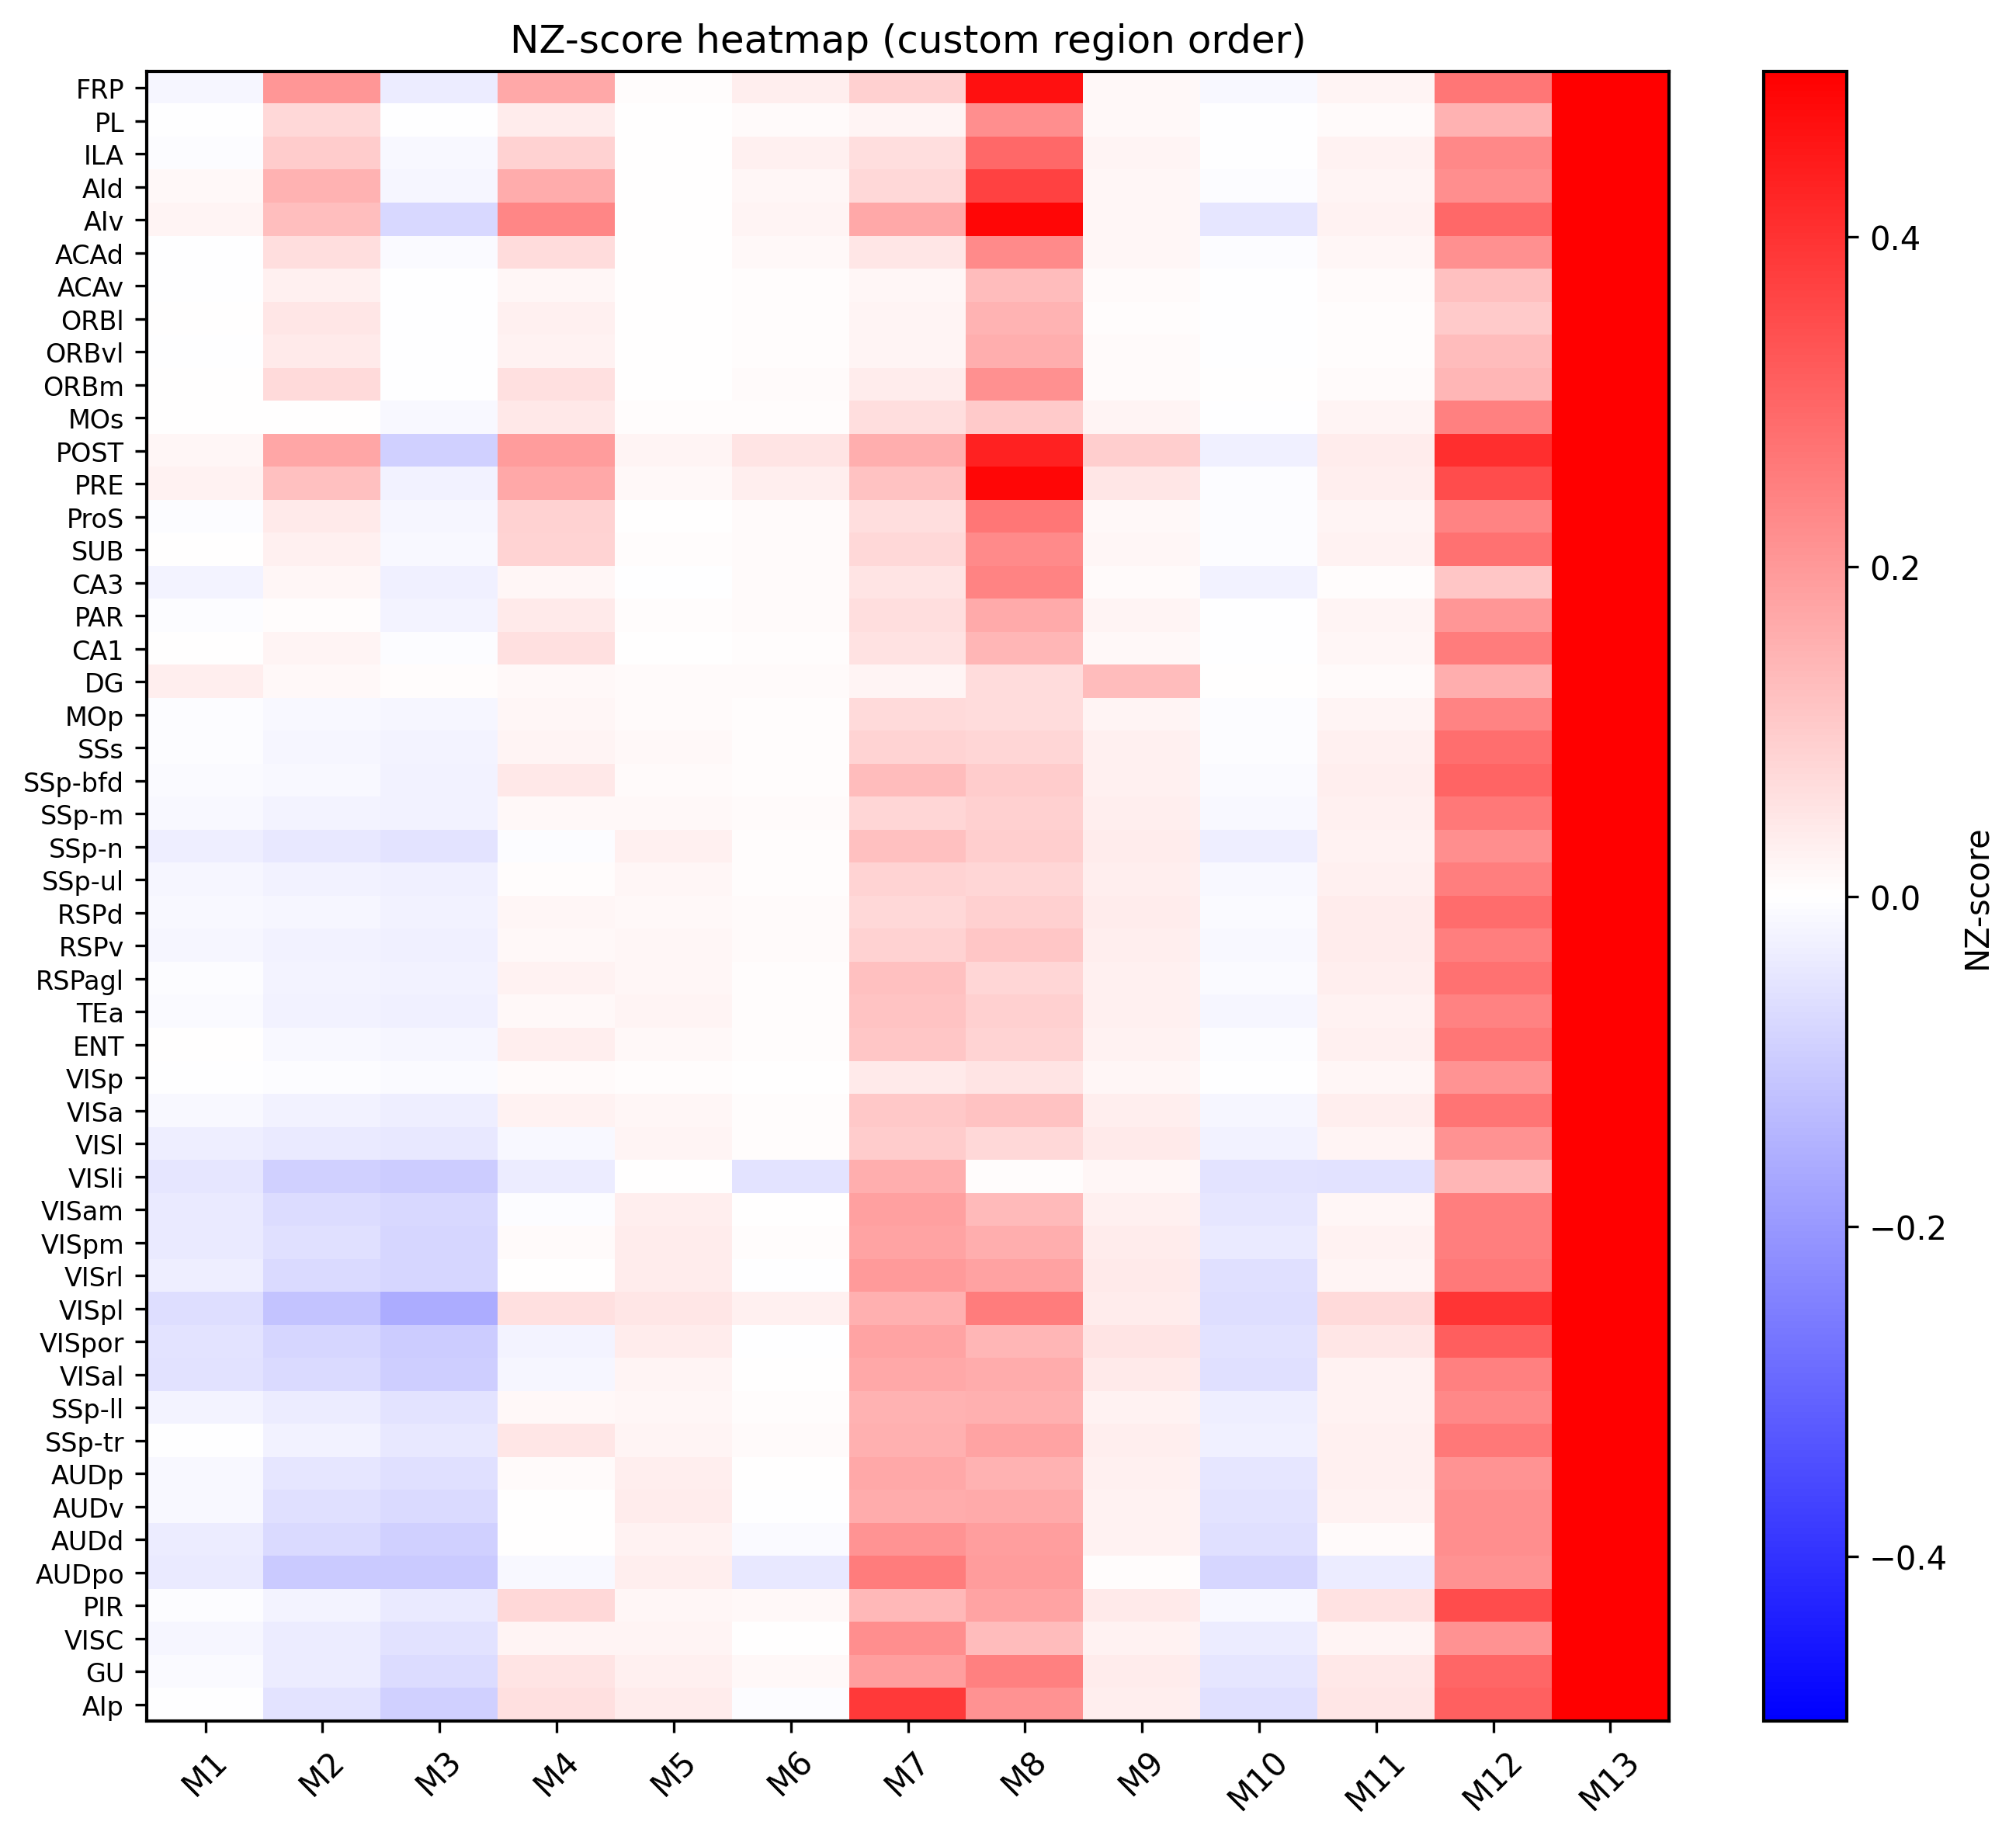

In [ ]:
import pickle
import numpy as np
import umap
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, optimal_leaf_ordering, dendrogram
from scipy.spatial.distance import pdist

import matplotlib as mpl

# ===== 提升整体分辨率 & 字体 =====
mpl.rcParams['figure.dpi'] = 300        # 屏幕显示分辨率
mpl.rcParams['savefig.dpi'] = 300       # 保存图片分辨率
mpl.rcParams['figure.figsize'] = (6, 4)
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.linewidth'] = 1.0
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

# ==================== 1. 加载 & 提取数据 ====================
with open("wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl", "rb") as f:
    data = pickle.load(f)["results"][5]

NZ, names, nodes, spars = [], [], [], []
for r, info in data.items():
    # 过滤掉不用的区域
    if r in {"SSp", "VPL", "PERI", "ECT", "PO", "PR"}:
        continue
    mr = info["motif_results"].get("0")
    if mr and (nz := np.asarray(mr["NZ"], float)).shape[0] == 13:
        names.append(r)
        NZ.append(nz)
        nodes.append(mr["node"])
        spars.append(mr["sparsity"])

NZ = np.vstack(NZ)
names = np.array(names)
nodes = np.array(nodes)
spars = np.array(spars, float)

# ==================== 2. UMAP + 聚类（这里只用来算 Z）====================
emb = umap.UMAP(
    n_neighbors=15,
    min_dist=0.15,
    metric='cosine',
    random_state=1
).fit_transform(NZ)

Z = optimal_leaf_ordering(linkage(emb, "ward"), pdist(emb))


# ==================== 3. 按你给的 cluster 顺序重排 ====================

# ---- 你给的 4 个 cluster 顺序 ----
cluster1_names = [
    "FRP",
    "PL",
    "ILA",
    "AId",
    "AIv",
    "ACAd",
    "ACAv",
    "ORBl",
    "ORBvl",
    "ORBm",
    "MOs",
]

cluster2_names = [
    "POST",
    "PRE",
    "ProS",
    "SUB",
    "CA3",
    "PAR",
    "CA1",
    "DG",
]

cluster3_names = [
    "MOp",
    "SSs",
    "SSp-bfd",
    "SSp-m",
    "SSp-n",
    "SSp-ul",
    "RSPd",
    "RSPv",
    "RSPagl",
    "TEa",
    "ENT",
    "VISp",
    "VISa",
    "VISl",
    "VISli",
]

cluster4_names = [
    "VISam",
    "VISpm",
    "VISrl",
    "VISpl",
    "VISpor",
    "VISal",
    "SSp-ll",
    "SSp-tr",
    "AUDp",
    "AUDv",
    "AUDd",
    "AUDpo",
    "PIR",
    "VISC",
    "GU",
    "AIp",
]

# 合并成一个总顺序
custom_order_names = (
    cluster1_names +
    cluster2_names +
    cluster3_names +
    cluster4_names
)

# 建一个 name -> index 映射
name_to_idx = {r: i for i, r in enumerate(names)}

# 检查一下是否有名字对不上
missing = [r for r in custom_order_names if r not in name_to_idx]
extra   = [r for r in names if r not in custom_order_names]

if missing:
    print("[WARN] 这些区域在数据里找不到，会被忽略:", missing)
if extra:
    print("[WARN] 数据里还有这些区域不在你给的顺序里，会按原顺序附加在最后:", extra)
# 先按照你给的顺序挑出确实存在的
ordered_names_list = [r for r in custom_order_names if r in name_to_idx]
# 再把剩下的（如果有的话）按原顺序放在最后
ordered_names_list += [r for r in names if r not in ordered_names_list]

# 这就是你后续要用的“统一顺序”（按名字）
region_order = ordered_names_list  # <-- 以后你可以直接用这个 list

# 把它转换成索引顺序
order = np.array([name_to_idx[r] for r in region_order], dtype=int)


# 自定义 cluster 标签（1~4），按名字映射
name_to_cluster = {}
for r in cluster1_names:
    name_to_cluster[r] = 1
for r in cluster2_names:
    name_to_cluster[r] = 2
for r in cluster3_names:
    name_to_cluster[r] = 3
for r in cluster4_names:
    name_to_cluster[r] = 4

# 对没有出现在 4 个列表里的（如果有），给个 0 类
labels = np.array([name_to_cluster.get(r, 0) for r in names])

# 按新顺序重排所有数组
NZ     = sort_by_order(NZ)
names  = sort_by_order(names)
nodes  = sort_by_order(nodes)
spars  = sort_by_order(spars)
labels = sort_by_order(labels)
emb    = sort_by_order(emb)


# ==================== 图3：NZ-score 热图 ====================
plt.figure(figsize=(9, 8))
im = plt.imshow(NZ, aspect='auto', cmap='bwr', vmin=-0.5, vmax=0.5)
plt.colorbar(im, label="NZ-score")

# y 轴用当前 names（已经是按你给的顺序排好的）
plt.yticks(range(len(names)), names, fontsize=8)
plt.xticks(range(13), [f"M{i+1}" for i in range(13)], rotation=45)
plt.title("NZ-score heatmap (custom region order)")
plt.tight_layout()
# plt.savefig("3.nz_score_heatmap.svg",
#             bbox_inches='tight', dpi=300, transparent=True)
plt.show()

In [49]:
data['MOp']['motif_results']['0.1']['str_threshold']

1.18958181142807

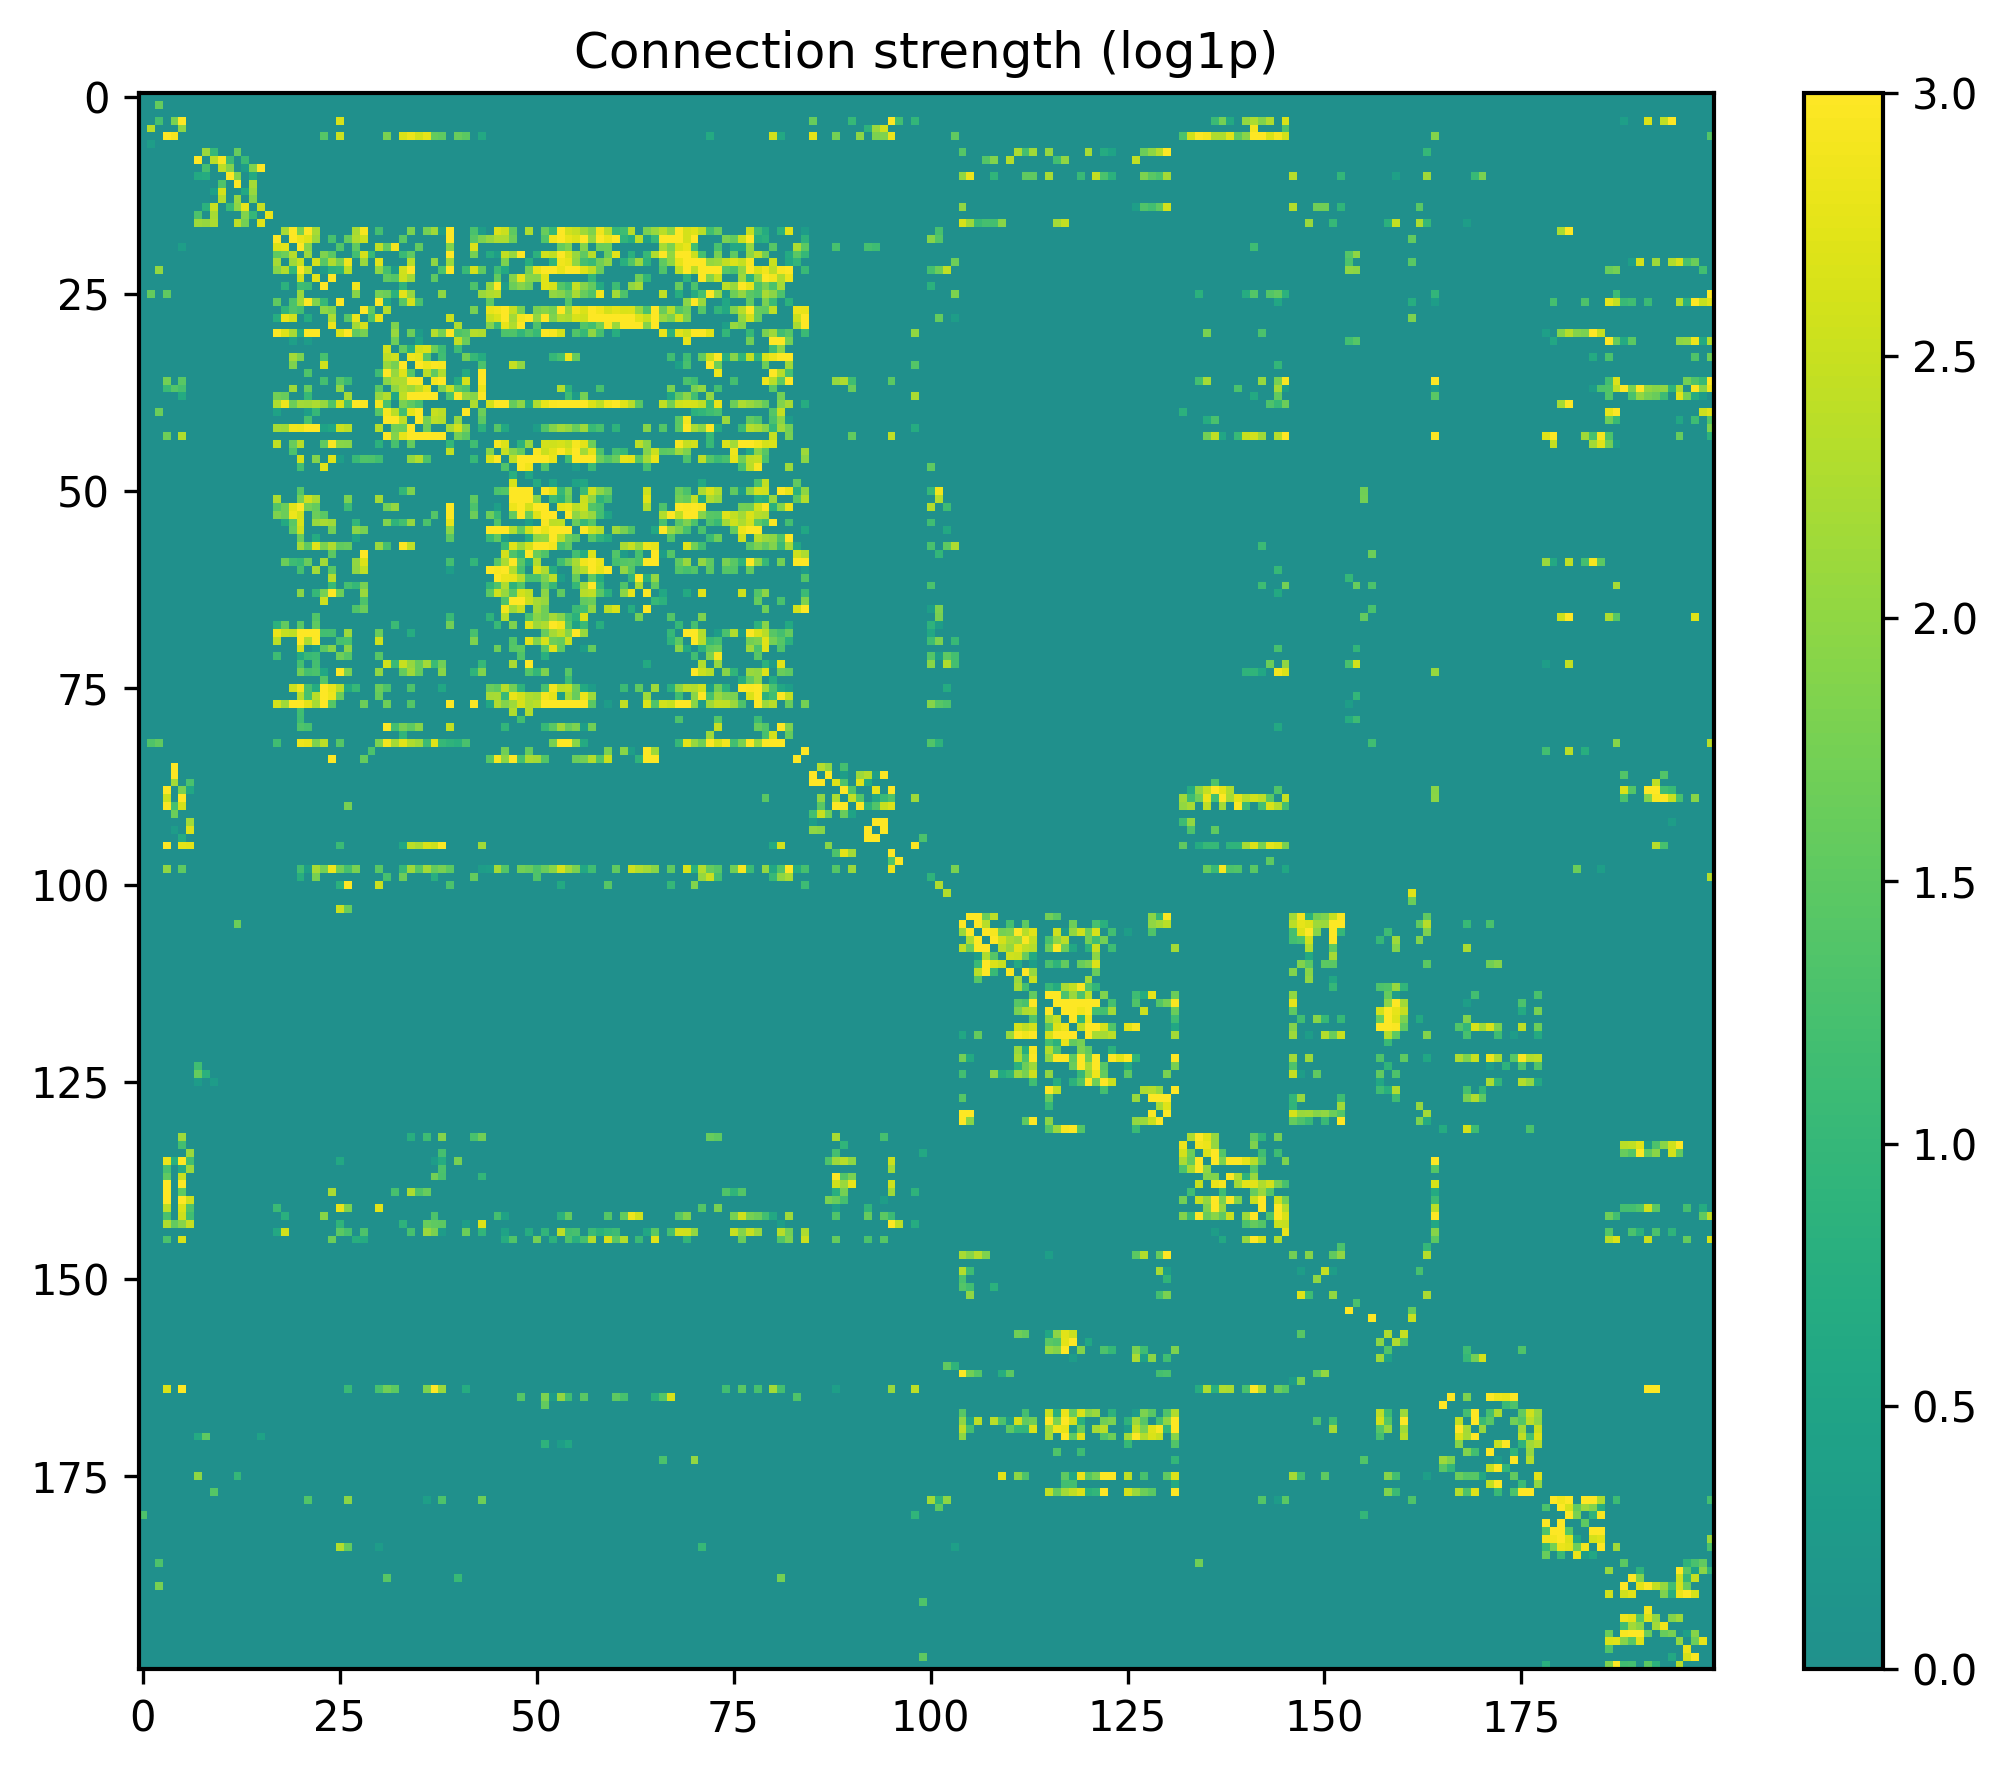

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


with open("wb_alltype_sc_results_dict_with_NZ_ES_norm.pkl", "rb") as f:
    data = pickle.load(f)["results"][5]
W = np.asarray(data['MOp']['sc'])[400:600,400:600]
W_log = np.log1p(W)

plt.figure(figsize=(8, 6))

# 使用中等偏浅的部分
cmap4 = truncate_colormap(plt.cm.viridis, 0.5,1)
im4 = plt.imshow(W_log, aspect='equal', interpolation='nearest',vmax=3, cmap=cmap4)
plt.colorbar(im4, fraction=0.046, pad=0.04)
plt.title("Connection strength (log1p)")
plt.savefig("Connection strength (log1p,200neurons).svg", bbox_inches='tight',  dpi=300, transparent=True)

plt.tight_layout()
plt.show()

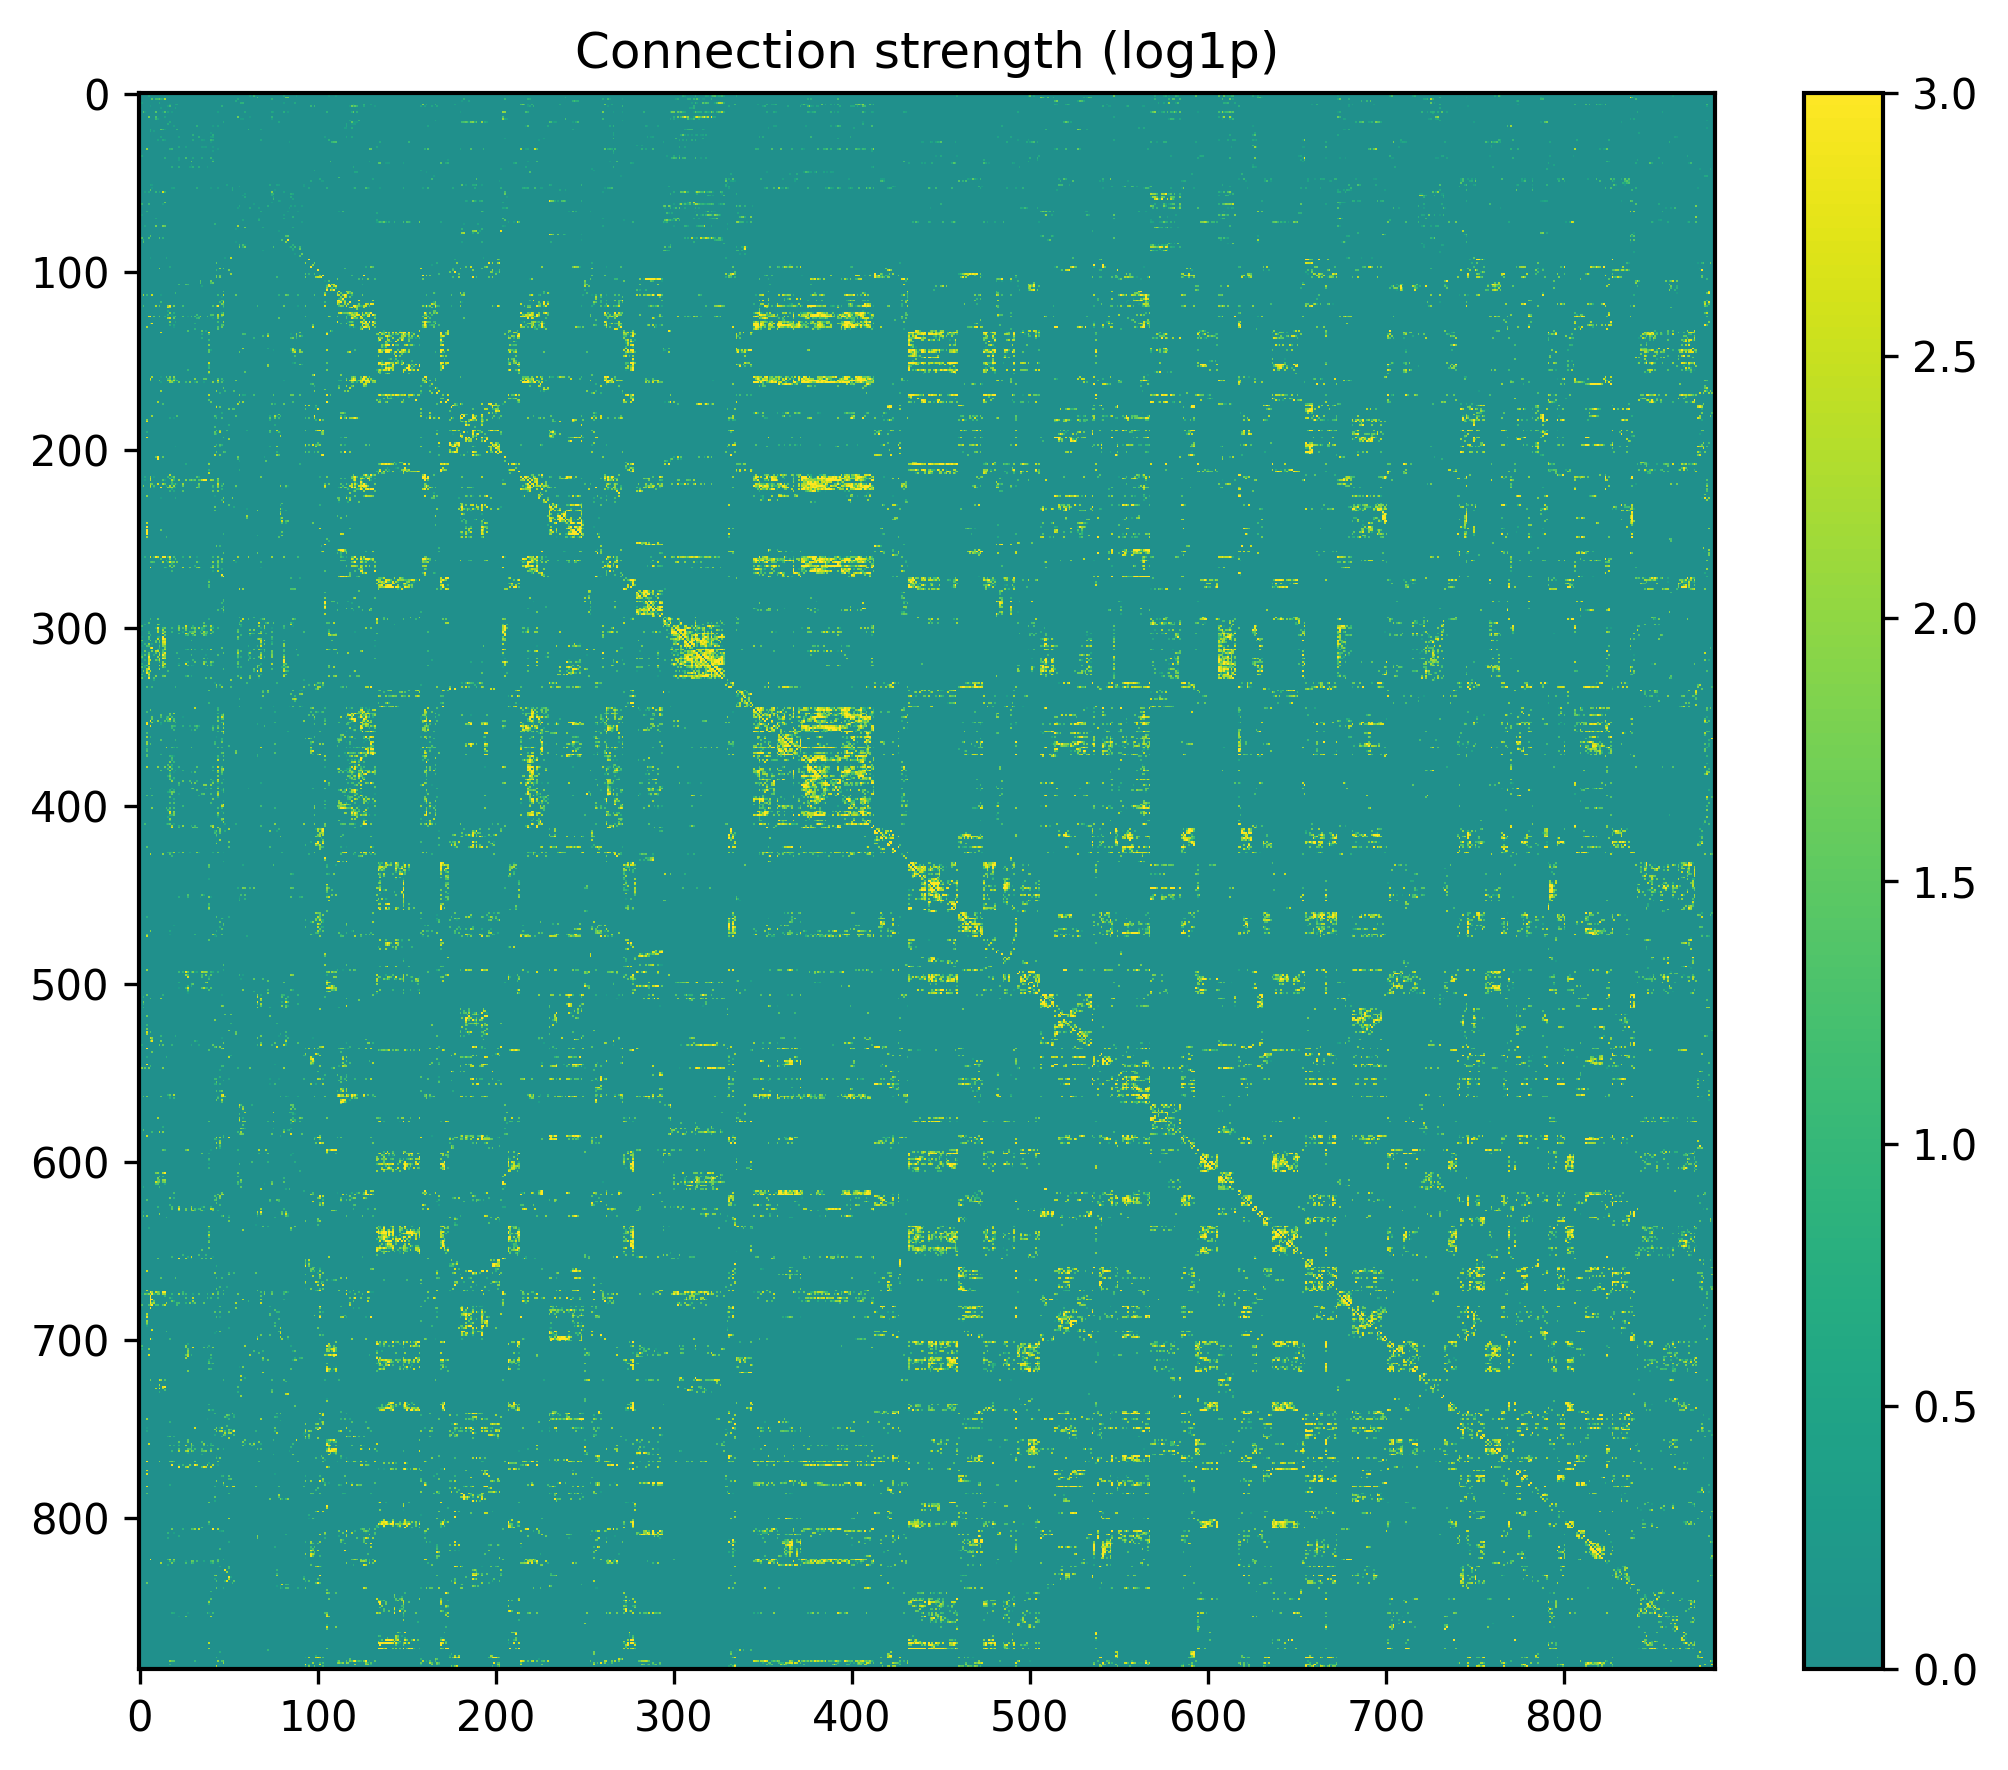

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


W = np.asarray(data['MOp']['sc'])[72:,72:]
W_log = np.log1p(W)

plt.figure(figsize=(8, 6))

# 使用中等偏浅的部分
cmap4 = truncate_colormap(plt.cm.viridis, 0.5,1)
im4 = plt.imshow(W_log, aspect='equal', interpolation='nearest',vmax=3, cmap=cmap4)
plt.colorbar(im4, fraction=0.046, pad=0.04)
plt.title("Connection strength (log1p)")
plt.savefig("Connection strength (log1p,900neurons).svg", bbox_inches='tight',  dpi=300, transparent=True)

plt.tight_layout()
plt.show()

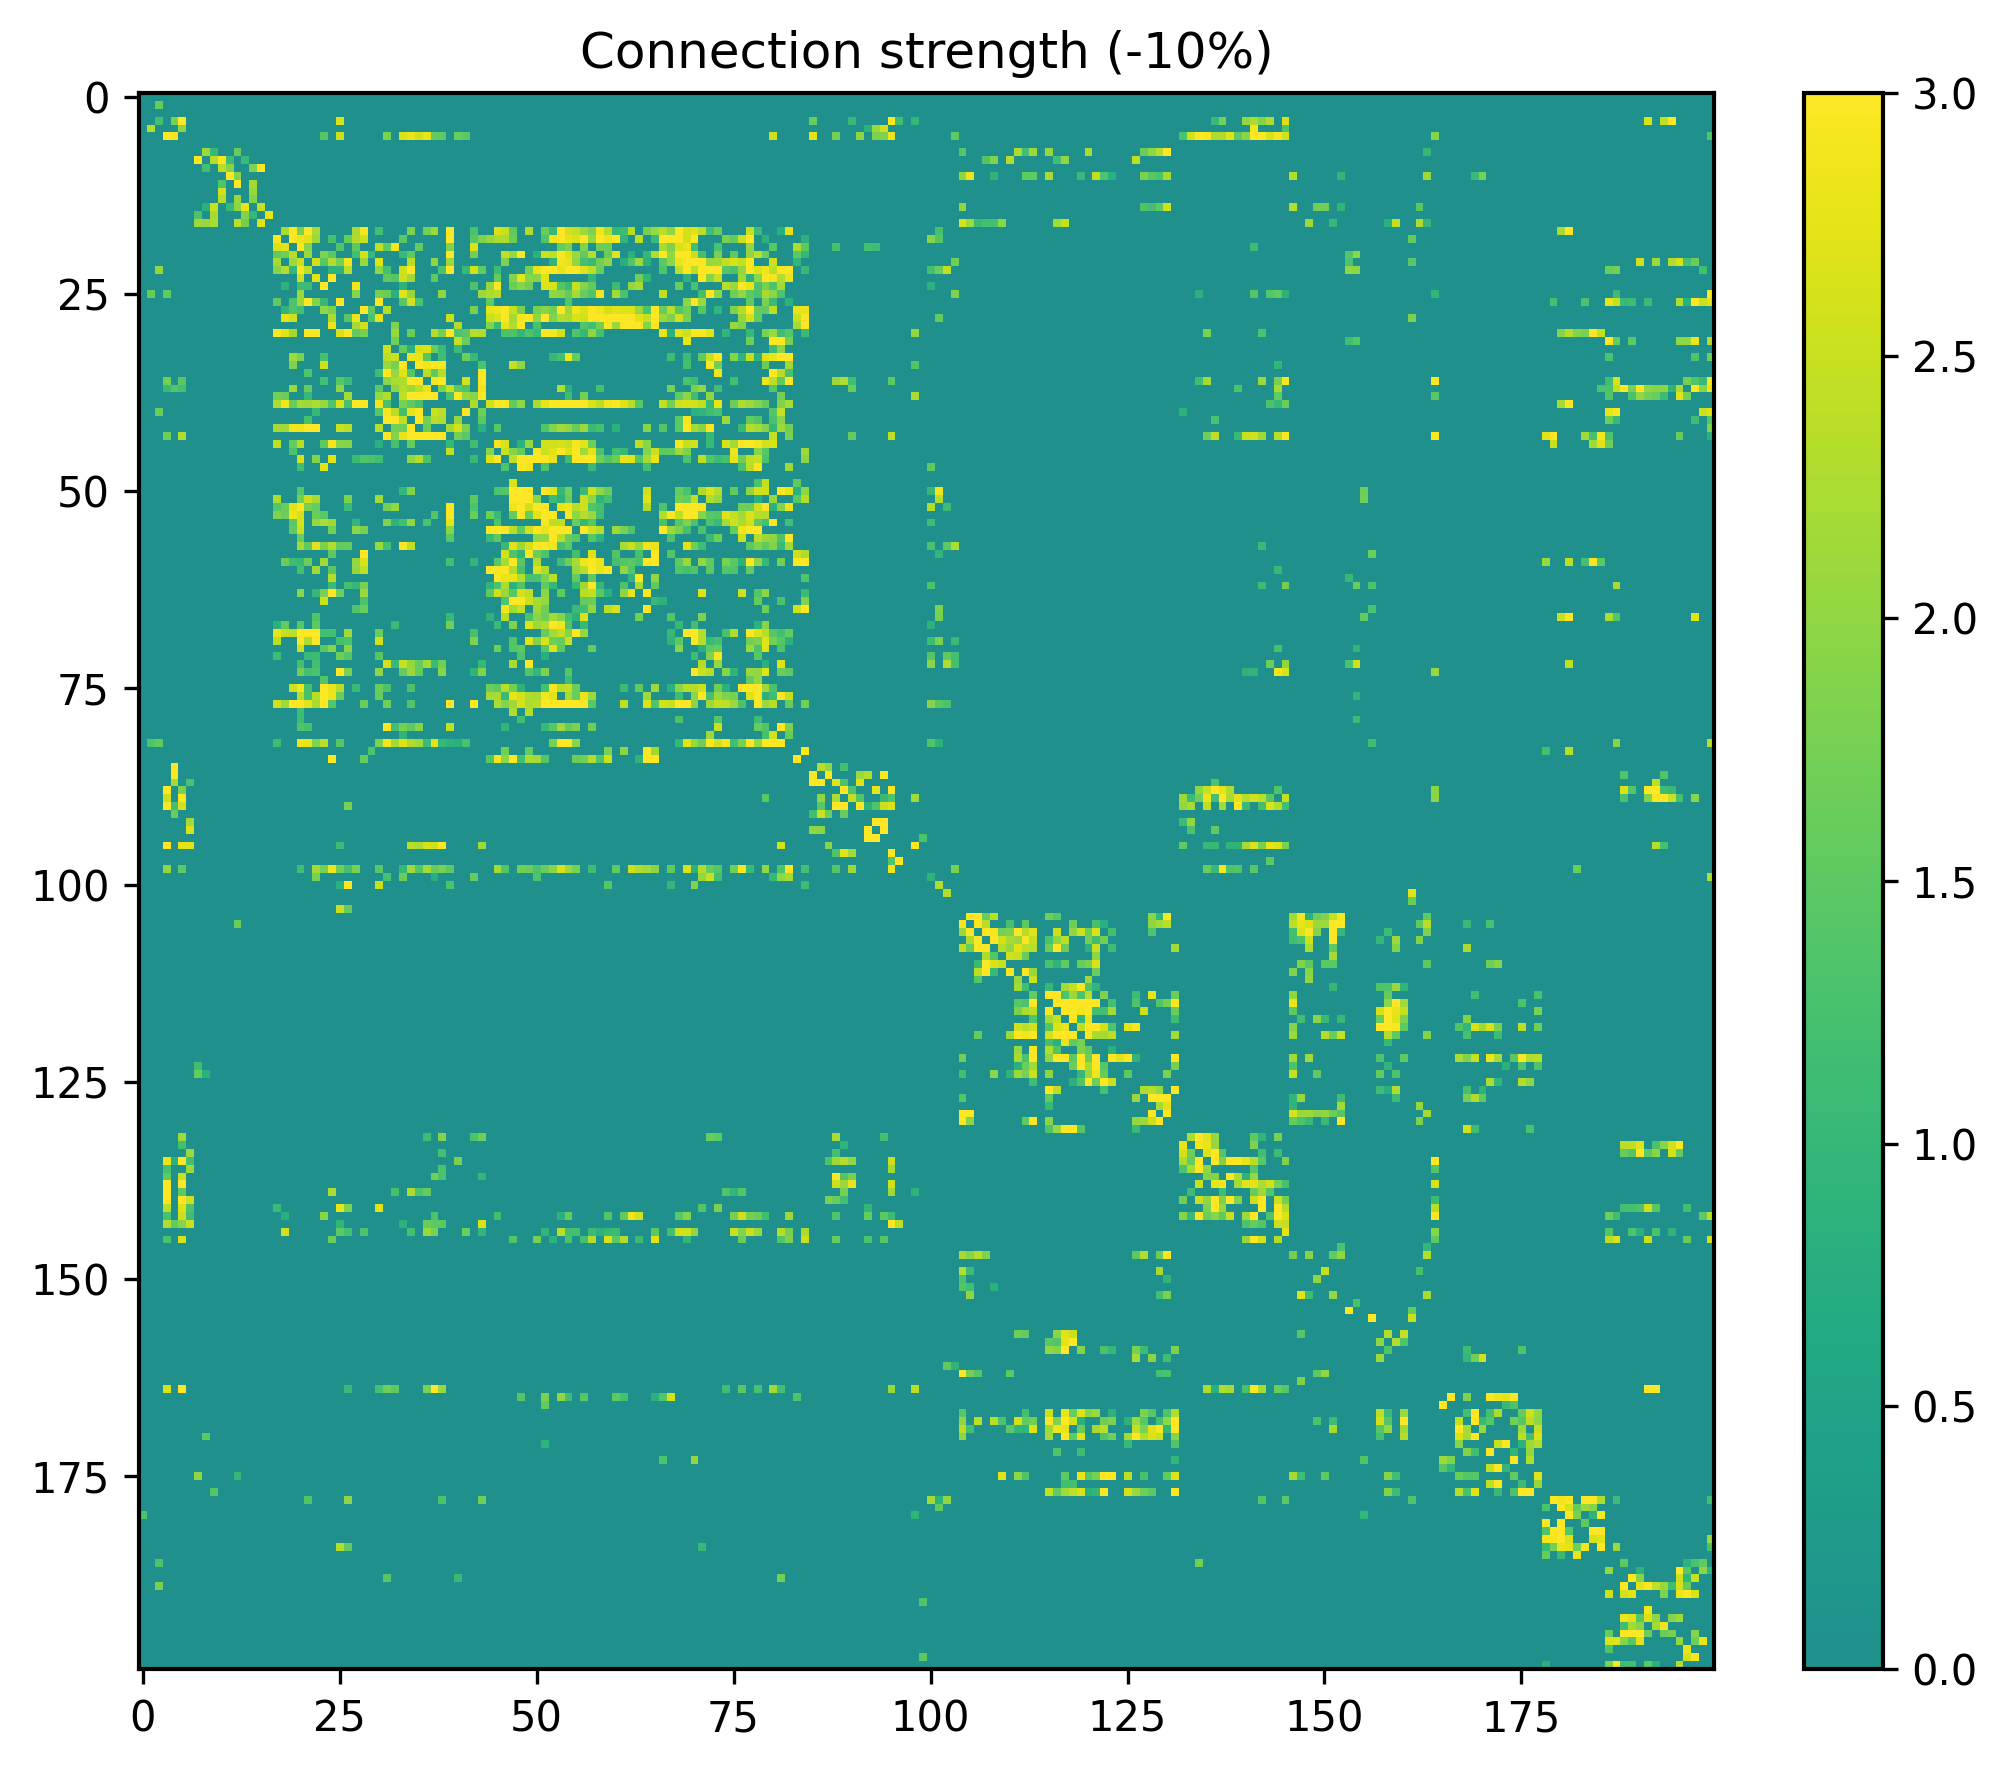

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


W = np.asarray(data['MOp']['sc'])[400:600, 400:600].astype(float)

# ✅ 原始阈值：小于 0.01 的连接置 0
thr = data['MOp']['motif_results']['0.1']['str_threshold']
W[W < thr] = 0.0   # 如果你想按绝对值阈值，用下一行替换：
# W[np.abs(W) < thr] = 0.0

W_log = np.log1p(W)

plt.figure(figsize=(8, 6))

cmap4 = truncate_colormap(plt.cm.viridis, 0.5, 1.0)
im4 = plt.imshow(W_log, aspect='equal', interpolation='nearest', vmax=3, cmap=cmap4)
plt.colorbar(im4, fraction=0.046, pad=0.04)
plt.title(f"Connection strength (-10%)")

plt.tight_layout()
plt.show()

In [ ]:
data['MOp']['motif_results']['0.4']['str_threshold']


3.571805953979492

In [90]:
import numpy as np

W = np.asarray(data['MOp']['sc'])[72:, 72:]

mask = (W != 0) & np.isfinite(W)
min_nonzero = np.min(W[mask]) if np.any(mask) else None
print("min(W | W!=0) =", min_nonzero)

sum(W[W<1.0])

min(W | W!=0) = 3.5718691


0.0

In [ ]:
W = np.asarray(data['MOp']['sc'])




0.0

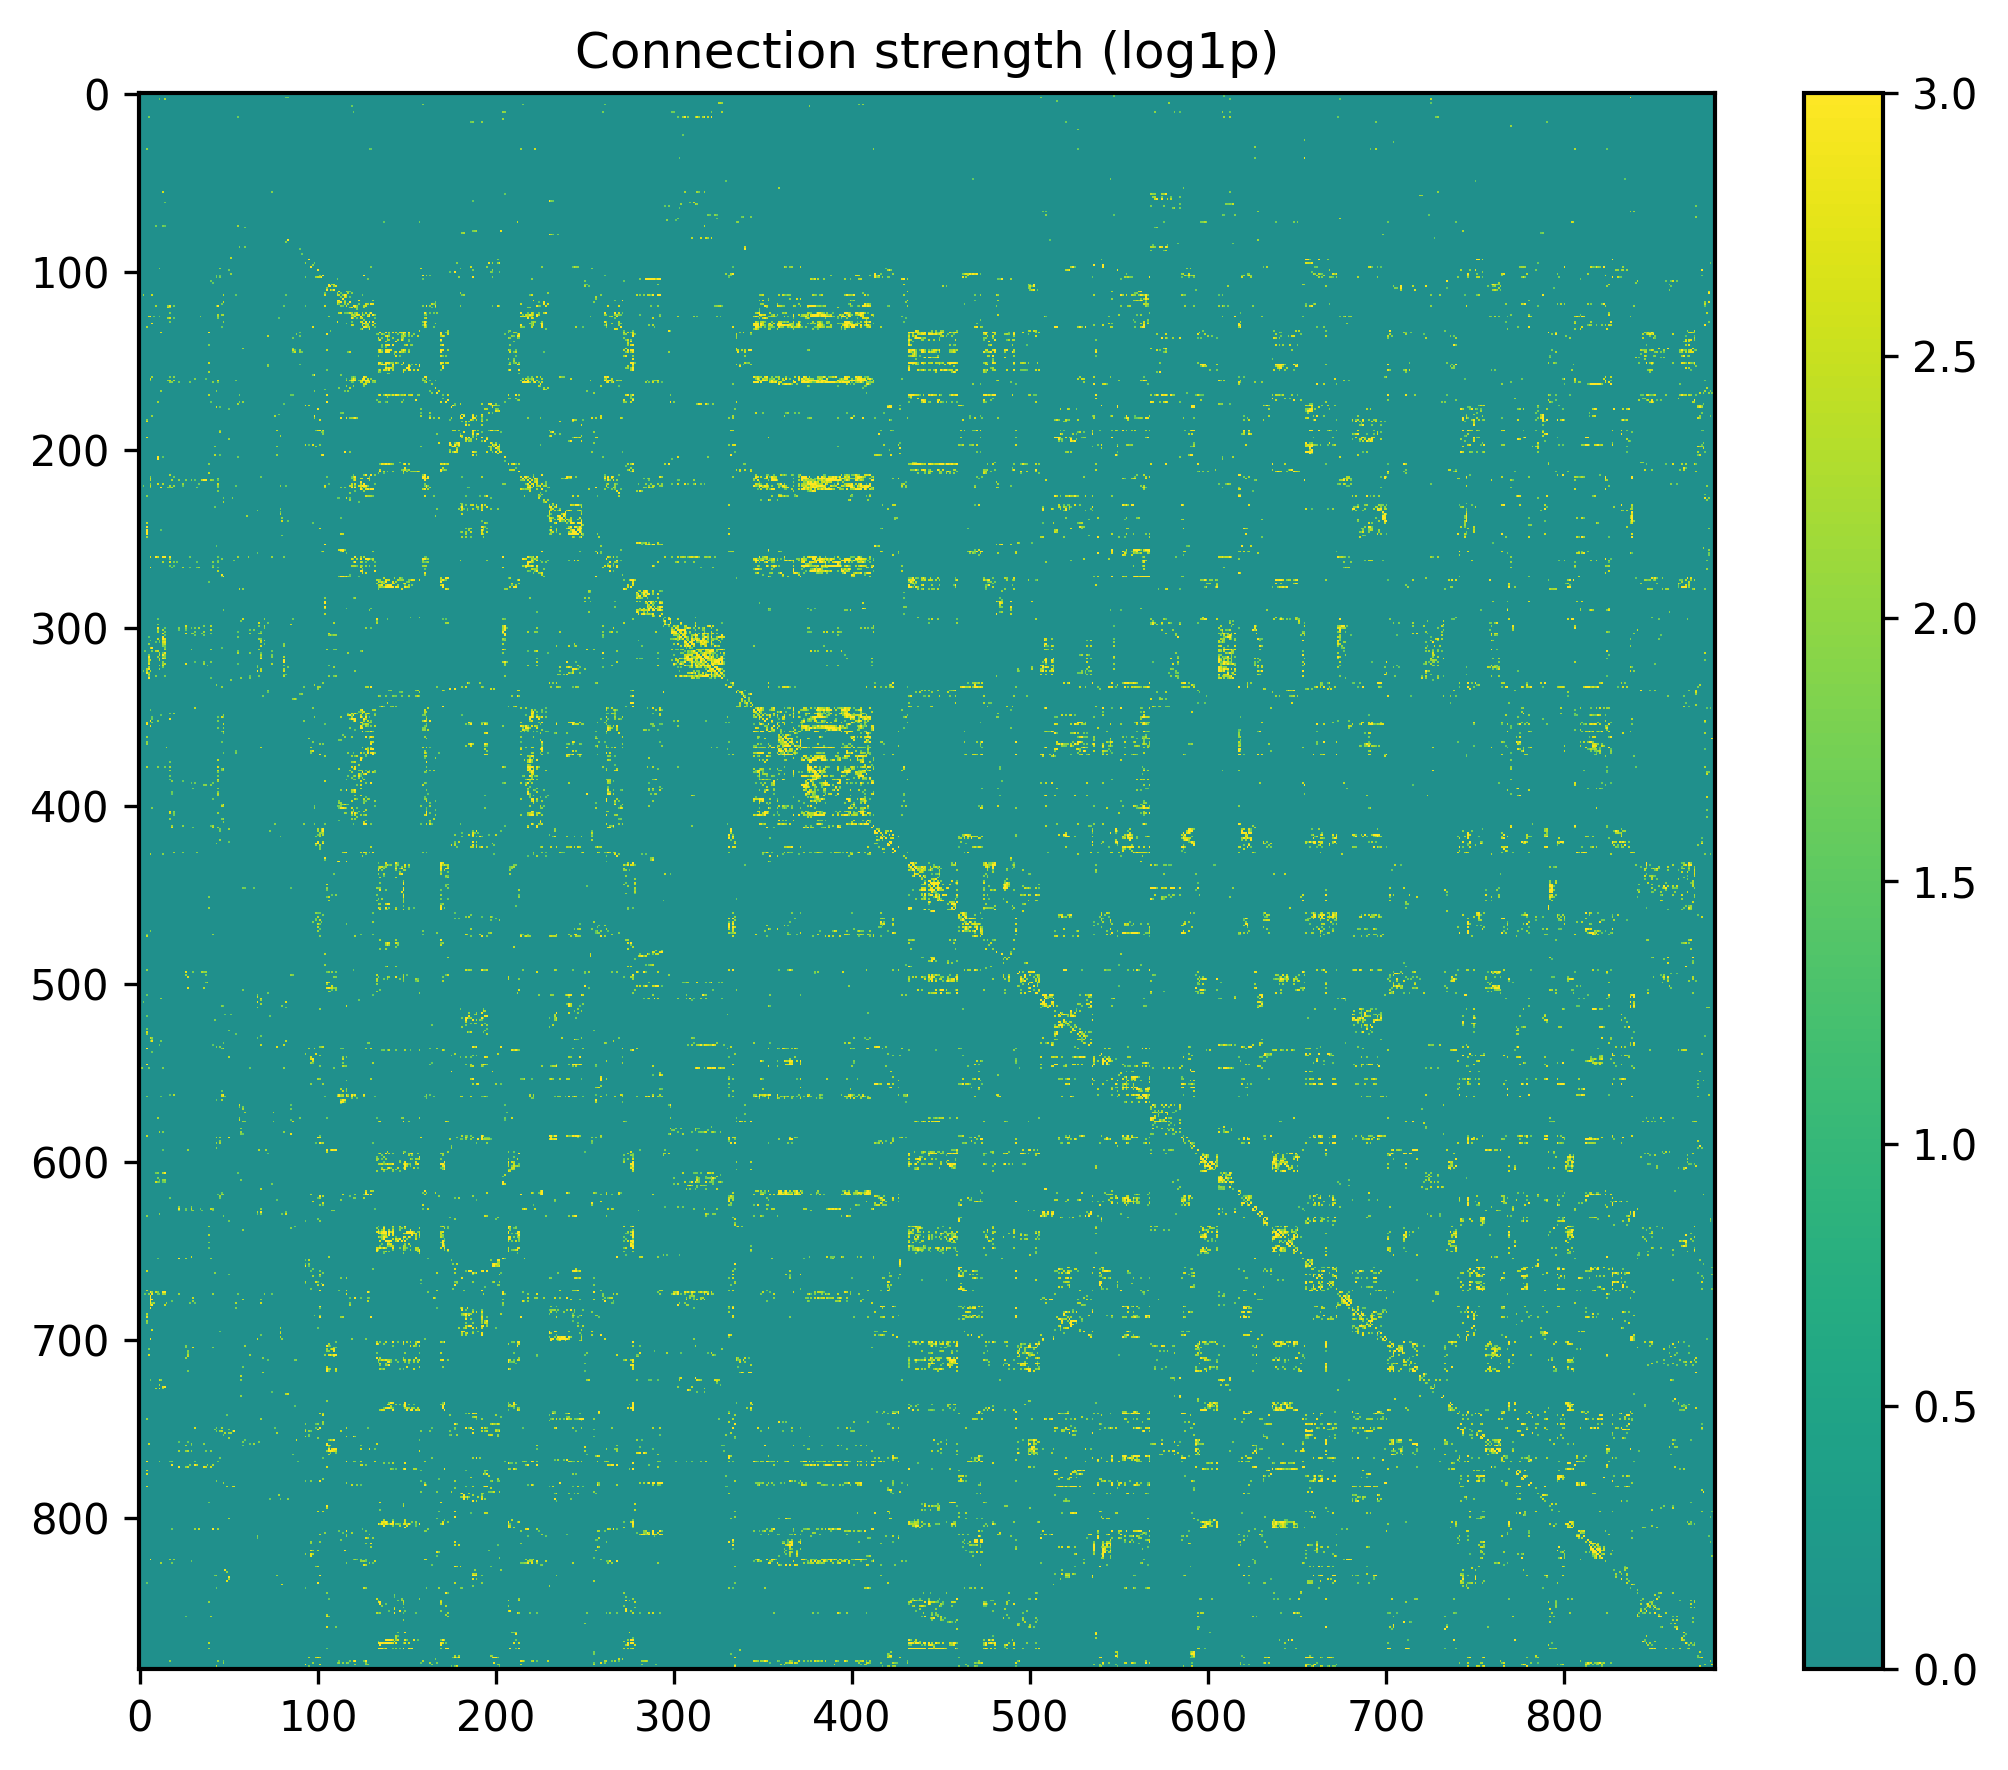

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


W = np.asarray(data['MOp']['sc'])[72:,72:]

thr = data['MOp']['motif_results']['0.4']['str_threshold']
W[W < thr] = 0.0 

W_log = np.log1p(W)

plt.figure(figsize=(8, 6))

# 使用中等偏浅的部分
cmap4 = truncate_colormap(plt.cm.viridis, 0.5,1)
im4 = plt.imshow(W_log, aspect='equal', interpolation='nearest',vmax=3, cmap=cmap4)
plt.colorbar(im4, fraction=0.046, pad=0.04)
plt.title("Connection strength (log1p)")
plt.savefig("Connection strength (log1p,900neurons).svg", bbox_inches='tight',  dpi=300, transparent=True)

plt.tight_layout()
plt.show()

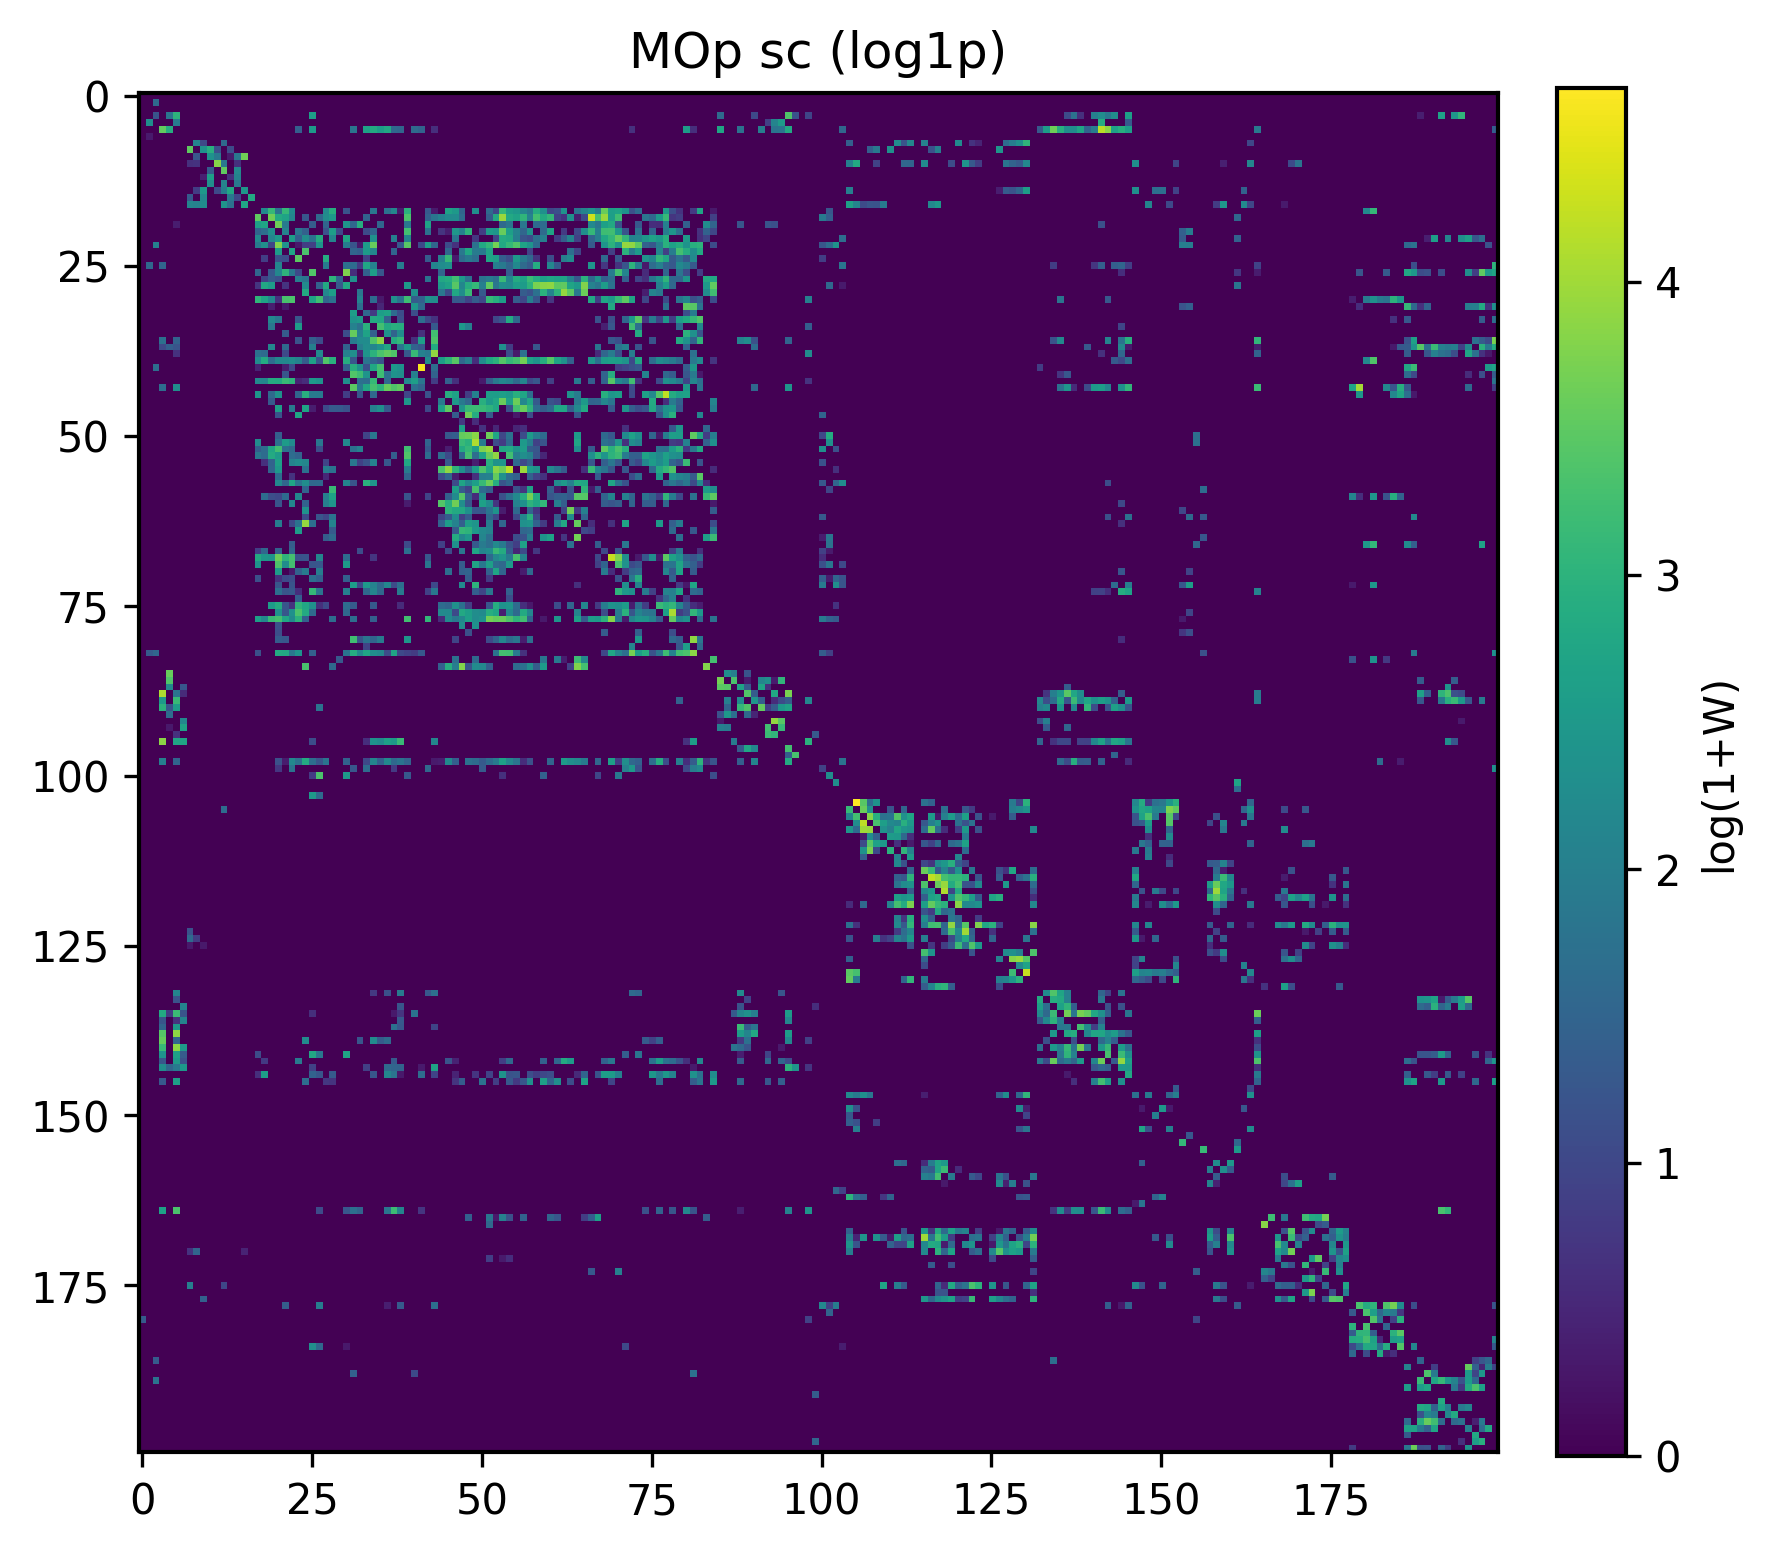

In [31]:
import numpy as np
import matplotlib.pyplot as plt

W = np.asarray(data['MOp']['sc'])[400:600,400:600]#[72:,72:]
W_log = np.log1p(W)  # 等价 log(1+W)

plt.figure(figsize=(6,6))
im = plt.imshow(W_log, aspect='equal', interpolation='nearest')
plt.colorbar(im, fraction=0.046, pad=0.04, label="log(1+W)")
plt.title("MOp sc (log1p)")
plt.tight_layout()
plt.show()